<a href="https://colab.research.google.com/github/KurniaYufi/nlp-sentiment-analisis/blob/main/Week4/Week4_Bibit_TF_IDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 4 - TF-IDF Bibit**

#1. Import Dependencies
Bagian ini menginisialisasi semua pustaka Python yang diperlukan untuk pemrosesan teks, perhitungan TF-IDF, serta visualisasi data.


In [2]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.7 MB/s eta 0:00:00


In [3]:
import io
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from wordcloud import WordCloud

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


#2. Data Load
Bagian ini mendefinisikan ulasan aplikasi Bibit yang akan diproses menggunakan metode TF-IDF untuk keperluan peringkasan.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df_review=pd.read_csv('/content/drive/MyDrive/NLP/bibit_reviews_cleaned.csv')
df_review.head()

,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_final
0,KECEWA sudah nggk bisa pencairan instan (sesam...,1,2026-04-05 07:00:34,0,"Hai kak, terkait hal tersebut terdapat update ...",negative,kecewa cair instan bank tunggu tuju bank jatah...,"['kecewa', 'cair', 'instan', 'bank', 'tunggu',..."
1,sangat bermanfaat buat menabung,5,2026-04-05 03:26:06,0,Terima kasih Kak Denny telah menjadi pengguna ...,positive,manfaat tabung,"['manfaat', 'tabung']"
2,saya sangat suka dimana bibit menjadi aplikasi...,4,2026-04-04 22:06:56,0,"Hai Kak Rizky, kami mohon maaf atas ketidaknya...",positive,suka cocok mula kasih bintang error buka bantu...,"['suka', 'cocok', 'mula', 'kasih', 'bintang', ..."
3,kenapa sekarang jatah Pencairan instan dibatas...,2,2026-04-04 13:47:36,0,Hai Kak Henry. Saat ini terdapat perubahan S &...,negative,jatah cair instan batas cair instan puas,"['jatah', 'cair', 'instan', 'batas', 'cair', '..."
4,"Gajelas, penambahn rekening baru gua ditolak, ...",1,2026-04-04 13:10:08,0,"Hai Kak Rapli, ketika tambah rekening, pastika...",negative,gajelas rekening gua tolak saldo gua nyangkut,"['gajelas', 'rekening', 'gua', 'tolak', 'saldo..."


In [17]:
if not df_review.empty and 'final_text' in df_review.columns:
    sentence = df_review['final_text'].head(100).tolist()

    print("Using first 100 preprocessed sentences from 'final_text' column of df_review:")
    for sent in sentence:
        print(sent)
else:
    print("Error: df_review is empty or 'final_text' column not found.")
    sentence = []

Using first 100 preprocessed sentences from 'final_text' column of df_review:
kecewa cair instan bank tunggu tuju bank jatah cair instan doang wkwkwk lawak ubah tengah jalan suka suka
manfaat tabung
suka cocok mula kasih bintang error buka bantu atas
jatah cair instan batas cair instan puas
gajelas rekening gua tolak saldo gua nyangkut
afk bagus aman terpercaya
mudah taut akun bank jago beda email sulit atur
oke
user friendly moga banyak jenis
manfaat ajar tabung
mudah paham
ngebug maintenance informasi utama libur fitur baru hilang cair instan produk tanda cair instan versi bagus cair instan batas timbang tarik aset ubah fitur
buka
diupdate cair instan batas tunggu aktivasi cari ribet
jujur update fitur instan bangga banget alas pakai iya tau instan spesial si kalo
well
bangkai rekening lihat nomor lihat verifikasi email tulis internet jelasjelas internet bagus lancar
bagus tingkat income pasif pensiun
aplikasi ganggu jaring bagus
good
data banget
maaf min login akun
koneksi lambat pa

#3. Scikit-learn TF-IDF Vectorization
Bagian ini menggunakan Tf-idf Vectorizer dari scikit-learn untuk secara efisien menghitung skor TF-IDF untuk semua kata di seluruh kalimat yang telah dibersihkan. Representasi dalam bentuk vektor ini kemudian digunakan untuk proses peringkasan (summarization).

In [18]:
# Step: Training TF-IDF Vectorizer pada kalimat ulasan Bibit

# Inisialisasi TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

# Melakukan fit dan transform pada data kalimat (sentence)
features = vectorizer.fit_transform(sentence)

# Mengambil daftar kata (fitur) yang terbentuk
feature_names = vectorizer.get_feature_names_out()

# Menampilkan hasil matriks TF-IDF (dalam bentuk sparse matrix)
print("\nTF-IDF Feature Matrix (Sparse) pada kalimat ulasan Bibit:")
print(features)

# Menampilkan ukuran matriks (jumlah kalimat, jumlah kata unik)
print("\nShape of the Feature Matrix (Jumlah kalimat, Jumlah kata unik):")
print(features.shape)

# Menampilkan daftar kata yang menjadi fitur
print("\nFeature Names (Kata dalam vocabulary):")
print(feature_names)


TF-IDF Feature Matrix (Sparse) pada kalimat ulasan Bibit:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 670 stored elements and shape (100, 369)>
  Coords	Values
  (0, 148)	0.19641224535052068
  (0, 54)	0.28508709475780314
  (0, 117)	0.3069700696599545
  (0, 33)	0.3598277338335985
  (0, 342)	0.17991386691679925
  (0, 339)	0.24134109713804527
  (0, 132)	0.22145976350287505
  (0, 79)	0.24134109713804527
  (0, 366)	0.24134109713804527
  (0, 167)	0.24134109713804527
  (0, 346)	0.22145976350287505
  (0, 321)	0.24134109713804527
  (0, 127)	0.19641224535052068
  (0, 300)	0.4429195270057501
  (1, 189)	0.7071067811865476
  (1, 307)	0.7071067811865476
  (2, 300)	0.3503318344897776
  (2, 64)	0.32801720931912476
  (2, 207)	0.2651158138299882
  (2, 146)	0.31070864134202375
  (2, 47)	0.3503318344897776
  (2, 85)	0.3817825322343459
  (2, 49)	0.32801720931912476
  (2, 34)	0.28460951122750444
  (2, 20)	0.3817825322343459
  :	:
  (94, 69)	0.19331916182480413
  (94, 335)	0.22836650114179

#4. TF-IDF Analysis and Summarization
Bagian ini menjelaskan penerapan TfidfVectorizer untuk menghitung skor TF-IDF pada tingkat kata dan kalimat. Selain itu, dilakukan analisis skor TF-IDF pada setiap kata dalam sebuah kalimat contoh untuk memberikan pemahaman dasar, sebelum melanjutkan ke proses peringkasan yang didasarkan pada rata-rata skor TF-IDF pada tingkat kalimat.

In [19]:
if sentence:
    # Mengambil nilai TF-IDF untuk kalimat pertama
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nNilai TF-IDF untuk kalimat pertama:")
    print(first_cleaned_sentence_tfidf)

    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Mengembalikan DataFrame berisi nilai TF-IDF untuk satu kalimat tertentu."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({
            'Kata': feature_names,
            'TF-IDF': sentence_tfidf_values
        })
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    # Mengambil dan menampilkan TF-IDF dalam bentuk tabel untuk kalimat pertama
    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nNilai TF-IDF untuk kalimat pertama (sudah diurutkan):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nTidak ada kalimat ulasan yang dapat diproses.")


Nilai TF-IDF untuk kalimat pertama:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.35982773 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.28508709 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.2413411  0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0

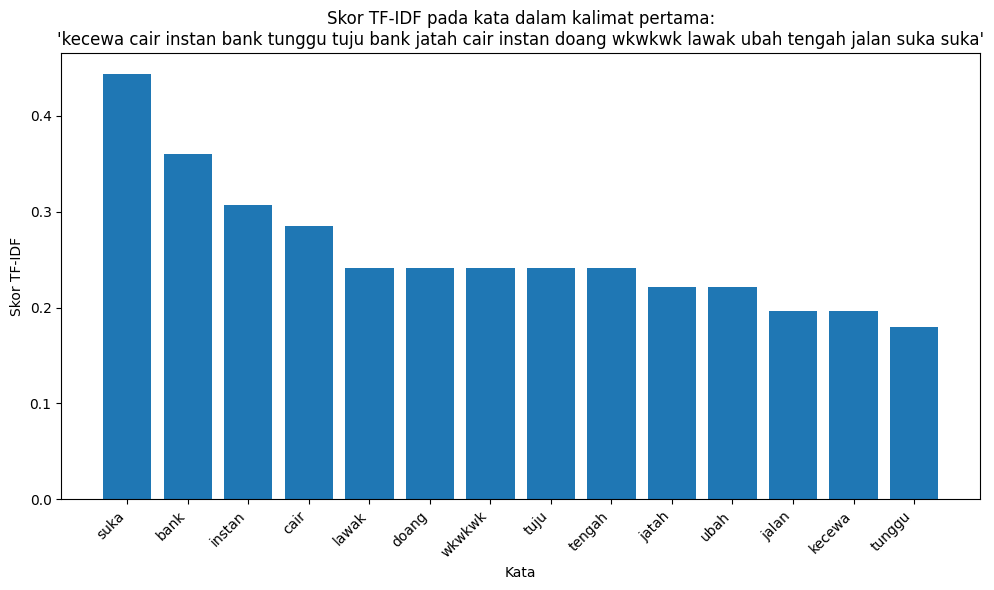

In [20]:
if sentence:
    first_cleaned_sentence = sentence[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualisasi nilai TF-IDF dalam bentuk diagram batang
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Kata'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Kata")
    plt.ylabel("Skor TF-IDF")
    plt.title(f"Skor TF-IDF pada kata dalam kalimat pertama:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada kalimat ulasan yang dapat divisualisasikan.")

#5. Average TF-IDF Score Calculation and Visualization
Pada bagian ini, rata-rata skor TF-IDF untuk setiap kalimat dihitung. Kalimat dengan nilai rata-rata yang lebih tinggi dianggap lebih penting. Hasil tersebut kemudian divisualisasikan dalam bentuk histogram, disertai dengan penjelasan mengenai cara menginterpretasikan histogram tersebut.

In [21]:
sent_index = 0
sent_scores = []

print("\nPerhitungan rata-rata skor TF-IDF untuk setiap kalimat ulasan Bibit:")

# Menghitung rata-rata TF-IDF tiap kalimat
for i in features:
    print(f"- Kalimat {sent_index + 1}")

    sent_score = i.sum()
    sent_length = len(i.data)

    print(f"  Total skor TF-IDF: {sent_score:.4f}")
    print(f"  Jumlah kata: {sent_length}")

    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print(f"  Rata-rata skor TF-IDF: {avg_score:.4f}")

    sent_scores.append(avg_score)
    sent_index += 1

print("\n-------------------------")

# Menghitung threshold (rata-rata dari semua skor kalimat)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print(f"\nNilai threshold (rata-rata seluruh skor kalimat): {threshold:.4f}")


Perhitungan rata-rata skor TF-IDF untuk setiap kalimat ulasan Bibit:
- Kalimat 1
  Total skor TF-IDF: 3.6172
  Jumlah kata: 14
  Rata-rata skor TF-IDF: 0.2584
- Kalimat 2
  Total skor TF-IDF: 1.4142
  Jumlah kata: 2
  Rata-rata skor TF-IDF: 0.7071
- Kalimat 3
  Total skor TF-IDF: 2.9807
  Jumlah kata: 9
  Rata-rata skor TF-IDF: 0.3312
- Kalimat 4
  Total skor TF-IDF: 2.2032
  Jumlah kata: 5
  Rata-rata skor TF-IDF: 0.4406
- Kalimat 5
  Total skor TF-IDF: 2.3399
  Jumlah kata: 6
  Rata-rata skor TF-IDF: 0.3900
- Kalimat 6
  Total skor TF-IDF: 1.9556
  Jumlah kata: 4
  Rata-rata skor TF-IDF: 0.4889
- Kalimat 7
  Total skor TF-IDF: 2.9745
  Jumlah kata: 9
  Rata-rata skor TF-IDF: 0.3305
- Kalimat 8
  Total skor TF-IDF: 1.0000
  Jumlah kata: 1
  Rata-rata skor TF-IDF: 1.0000
- Kalimat 9
  Total skor TF-IDF: 2.2323
  Jumlah kata: 5
  Rata-rata skor TF-IDF: 0.4465
- Kalimat 10
  Total skor TF-IDF: 1.7294
  Jumlah kata: 3
  Rata-rata skor TF-IDF: 0.5765
- Kalimat 11
  Total skor TF-IDF: 1.40

In [22]:
# Mengambil kalimat ulasan Bibit yang memiliki skor di atas threshold
filtered_sentences_with_scores = []

for index, score in enumerate(sent_scores):
    if score >= threshold:
        filtered_sentences_with_scores.append((sentence[index], score))

# Mengurutkan kalimat berdasarkan skor TF-IDF tertinggi
sorted_sentences = sorted(filtered_sentences_with_scores, key=lambda x: x[1], reverse=True)

# Menampilkan 5 kalimat terbaik
print("\n5 Kalimat Terpenting dari Ulasan Bibit (berdasarkan skor TF-IDF):")

if sorted_sentences:
    for i, (s, score) in enumerate(sorted_sentences[:5]):
        print(f"{i+1}. Skor: {score:.4f} - {s}")
else:
    print("Tidak ada kalimat yang memenuhi kriteria threshold.")


5 Kalimat Terpenting dari Ulasan Bibit (berdasarkan skor TF-IDF):
1. Skor: 1.0000 - oke
2. Skor: 1.0000 - buka
3. Skor: 1.0000 - well
4. Skor: 1.0000 - good
5. Skor: 1.0000 - mantap


#6. Generated Summary
Langkah ini menyaring kalimat berdasarkan apakah rata-rata skor TF-IDF-nya memenuhi atau melebihi nilai threshold yang telah dihitung, kemudian menggabungkannya menjadi ringkasan akhir dari dokumen.

In [23]:
# Inisialisasi ringkasan akhir
final_summ = ""

print("\nKalimat ringkasan dari ulasan Bibit (di atas atau sama dengan threshold):")

# Mengambil kalimat yang memenuhi threshold
for index, score in enumerate(sent_scores):
    if score >= threshold:
        final_summ += " " + sentence[index]
        print(f"- {sentence[index]}")

# Menampilkan hasil ringkasan akhir
print("\nRingkasan Akhir Ulasan Bibit:")
print(final_summ.strip())


Kalimat ringkasan dari ulasan Bibit (di atas atau sama dengan threshold):
- manfaat tabung
- oke
- manfaat ajar tabung
- mudah paham
- buka
- well
- good
- data banget
- mantap apl
- tolol ribet lot
- mantap
- bagus
- nice
- very good
- baik main uang
- top markotop
- coba cocok
- revisi
- jos
- respon chat banget
- bagus
- bangus
- bagus aplikasi diupdate
- oke nabung
- aplikasi bagus banget
- bukaa yaa
- tarik uang banget
- masuk malas
- moga jangka
- kode refferal
- bagus
- langsung cair dana
- mantap inves perdana
- transaksi aman
- salah baik indonesia
- bagus
- kode referral tau
- solusi
- bagus

Ringkasan Akhir Ulasan Bibit:
manfaat tabung oke manfaat ajar tabung mudah paham buka well good data banget mantap apl tolol ribet lot mantap bagus nice very good baik main uang top markotop coba cocok revisi jos respon chat banget bagus bangus bagus aplikasi diupdate oke nabung aplikasi bagus banget bukaa yaa tarik uang banget masuk malas moga jangka kode refferal bagus langsung cair d